# 08 - LightGBM for Enrollment Forecasting

Main idea -> we flatten each student's 3-semester sliding window (3 x 154 = 462 features) and feed it to a per-course `LGBMClassifier`. This gives us enrollment probabilities that we then sum across all students in each test semester to produce course-level enrollment counts, the same aggregation the Micro LSTM uses, which makes the MAE comparison direct and fair.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, r2_score

from educast.config import (
    NUM_COURSES, FEAT_DIM_STUDENT, MICRO_WINDOW_SIZE, SPLIT_YEAR, RANDOM_SEED
)
from educast.data.loader import load_university_json, build_course_vocabulary, build_course_label_map
from educast.features.multihot import build_student_dataset
from educast.data.splits import split_by_year
from educast.evaluation.metrics import compute_mae, per_course_mae
from educast.evaluation.export import export_results, build_experiment_metadata

sns.set_style("whitegrid")
print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## 1. Data Preparation

In [2]:
university_data = load_university_json()
course_ids, course_to_idx, idx_to_course = build_course_vocabulary(university_data)
labels = build_course_label_map(university_data, idx_to_course)

X_all, y_all, meta_all = build_student_dataset(
    university_data, course_to_idx, window_size=MICRO_WINDOW_SIZE
)

X_train, y_train, meta_train, X_test, y_test, meta_test = split_by_year(
    X_all, y_all, meta_all, split_year=SPLIT_YEAR
)

# Flatten windows: (n, 3, 154) -> (n, 462) for tree-based models
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Train: {len(X_train)} samples (years < {SPLIT_YEAR})")
print(f"Test:  {len(X_test)} samples (years >= {SPLIT_YEAR})")
print(f"Flattened feature dim: {X_train_flat.shape[1]}")

Train: 1322 samples (years < 2018)
Test:  836 samples (years >= 2018)
Flattened feature dim: 462


## 2. Training one LGBMClassifier per Course

In [3]:
lgb_models = {}
lgb_student_results = {}  # per-subject classification metrics

for c_idx in range(NUM_COURSES):
    y_tr = y_train[:, c_idx]
    y_te = y_test[:, c_idx]

    if y_tr.sum() == 0 or y_te.sum() == 0:
        lgb_student_results[c_idx] = (0.0, 0.0, 0.0)
        continue

    clf = LGBMClassifier(
        n_estimators=200, max_depth=4, num_leaves=31,
        learning_rate=0.1, is_unbalance=True,
        reg_alpha=0.1, reg_lambda=1.0, min_child_samples=5,
        random_state=RANDOM_SEED, verbose=-1,
    )
    clf.fit(X_train_flat, y_tr)
    lgb_models[c_idx] = clf

    y_pred = clf.predict(X_test_flat)
    r = recall_score(y_te, y_pred, zero_division=0)
    p = precision_score(y_te, y_pred, zero_division=0)
    f = f1_score(y_te, y_pred, zero_division=0)
    lgb_student_results[c_idx] = (r, p, f)

n_trained = len(lgb_models)
n_skipped = NUM_COURSES - n_trained
avg_f1 = np.mean([f for r, p, f in lgb_student_results.values()])
print(f"Trained {n_trained} course models, skipped {n_skipped} (no positive samples)")
print(f"Student-level Avg F1: {avg_f1:.3f}")

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Trained 43 course models, skipped 8 (no positive samples)
Student-level Avg F1: 0.561


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3. Aggregating to Course-Level Enrollment Counts

The classifiers output enrollment probabilities for each student in each test semester. To obtain course-level enrollment counts, the quantity we actually want to forecast, we sum these probabilities across all students within each semester. This is identical to the aggregation step in the Micro LSTM evaluation, so the resulting MAE values are directly comparable.

We also compute a naive baseline (lag-2: same semester from the previous year) for reference.

In [4]:
# Get enrollment probabilities (not binary predictions)
student_agg = defaultdict(lambda: np.zeros(NUM_COURSES))
actual_agg = defaultdict(lambda: np.zeros(NUM_COURSES))

for i, (year, term, sid) in enumerate(meta_test):
    term_key = f"{year}-{term:02d}"
    actual_agg[term_key] += y_test[i]

    probs = np.zeros(NUM_COURSES)
    for c_idx, clf in lgb_models.items():
        probs[c_idx] = clf.predict_proba(X_test_flat[i:i+1])[:, 1][0]
    student_agg[term_key] += probs

terms = sorted(student_agg.keys())
predictions = np.array([student_agg[t] for t in terms])
actuals = np.array([actual_agg[t] for t in terms])

mae = compute_mae(actuals, predictions)
r2 = r2_score(actuals.ravel(), predictions.ravel())
print(f"LightGBM -- Global MAE: {mae:.2f} students/course")
print(f"LightGBM -- R2: {r2:.3f}")

# Naive baseline (lag=2: same semester last year)
naive_agg = defaultdict(lambda: np.zeros(NUM_COURSES))
for i, (year, term, sid) in enumerate(meta_all):
    term_key = f"{year}-{term:02d}"
    naive_agg[term_key] += y_all[i]

naive_predictions = []
for t in terms:
    year, sem = t.split("-")
    lag_key = f"{int(year)-1}-{sem}"
    naive_predictions.append(naive_agg.get(lag_key, np.zeros(NUM_COURSES)))
naive_predictions = np.array(naive_predictions)
mae_naive = compute_mae(actuals, naive_predictions)
print(f"Naive baseline MAE: {mae_naive:.2f}")
print(f"Micro LSTM reference MAE: ~1.73 (from notebook 02)")

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

...

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

LightGBM -- Global MAE: 1.68 students/course
LightGBM -- R2: 0.945
Naive baseline MAE: 1.69
Micro LSTM reference MAE: ~1.73 (from notebook 02)


/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/anassanhari/EPSEM/TFM/educast/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X d

## 4. Per-Course MAE analysis

Top 15 courses by MAE:
    Course        MAE       MAE+      MAE-
49  330248  12.592430  12.592430  0.000000
10  330102   5.027826   5.027826  0.000000
48  330247   4.319443   4.319443  0.000000
11  330119   3.904714   0.492584  8.454220
45  330244   3.552845   0.302872  7.886143
38  330237   3.089112   0.022959  7.177317
31  330230   2.807033   3.596049  0.834493
8   330099   2.788068   3.632329  0.677415
41  330240   2.411355   1.614947  4.402376
25  330224   2.366707   0.344408  3.883432
14  330213   2.304133   3.111290  1.227923
12  330120   2.240008   0.528263  3.523817
28  330227   2.223729   2.223729  0.000000
27  330226   2.150063   2.352901  0.933038
47  330246   2.070194   2.929193  0.924864


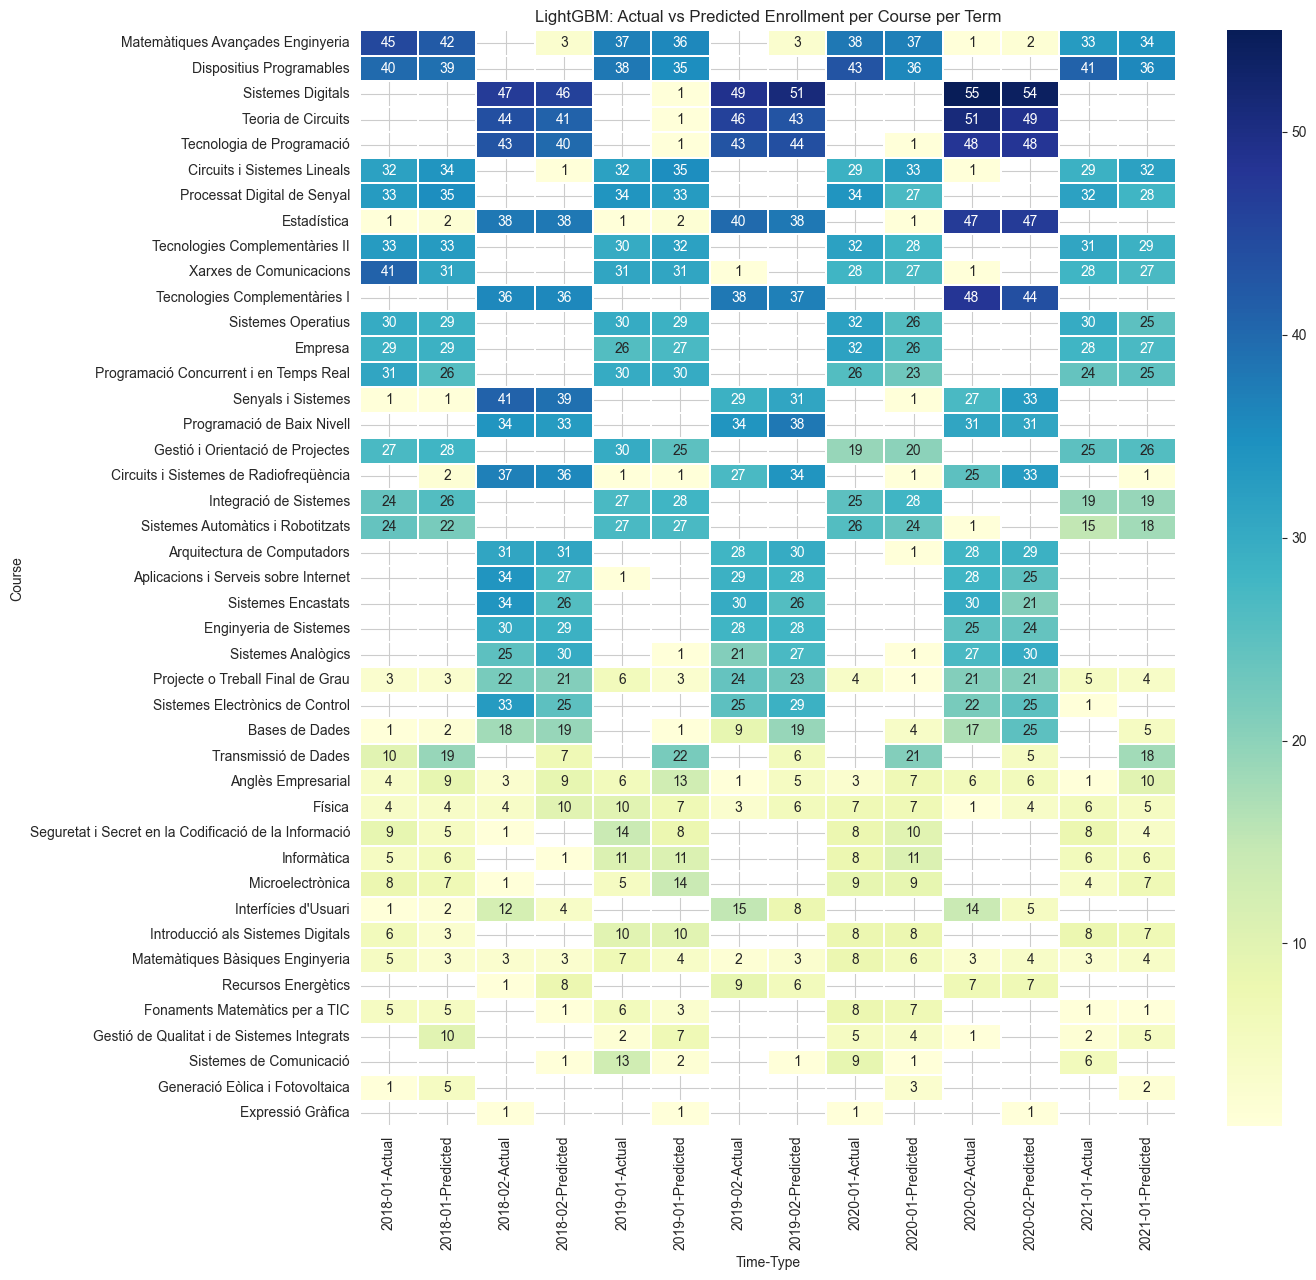

In [5]:
df_per_course = per_course_mae(actuals, predictions, {i: cid for i, cid in enumerate(course_ids)})
print("Top 15 courses by MAE:")
print(df_per_course.sort_values("MAE", ascending=False).head(15).to_string())

# Forecast heatmap
pred_rounded = np.round(predictions).astype(int)
actuals_rounded = np.round(actuals).astype(int)

records = []
for i, term in enumerate(terms):
    for c_idx in range(NUM_COURSES):
        a, p = actuals_rounded[i, c_idx], pred_rounded[i, c_idx]
        if a == 0 and p == 0:
            continue
        cname = labels.get(c_idx, f'ID_{c_idx}')
        records.append({'Course': cname, 'Time': term, 'Type': 'Actual', 'Count': a})
        records.append({'Course': cname, 'Time': term, 'Type': 'Predicted', 'Count': p})

df_heat = pd.DataFrame(records)
if not df_heat.empty:
    matrix = df_heat.groupby(['Course', 'Time', 'Type'])['Count'].sum().unstack(level=[1, 2], fill_value=0)
    matrix['Total'] = matrix.sum(axis=1)
    matrix = matrix.sort_values('Total', ascending=False).drop(columns=['Total'])

    plt.figure(figsize=(14, max(10, len(matrix) * 0.3)))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='YlGnBu', mask=matrix == 0,
                linewidths=0.1, linecolor='white')
    plt.title('LightGBM: Actual vs Predicted Enrollment per Course per Term')
    plt.tight_layout()
    plt.show()

## 5. Feature Importance

One advantage of tree-based models over neural networks is interpretable feature importance. LightGBM records how often each feature is used for splits and the gain those splits produce. Since our 462-dimensional input is structured as 3 timesteps of 154 features each, we can trace which features the model relies on most.

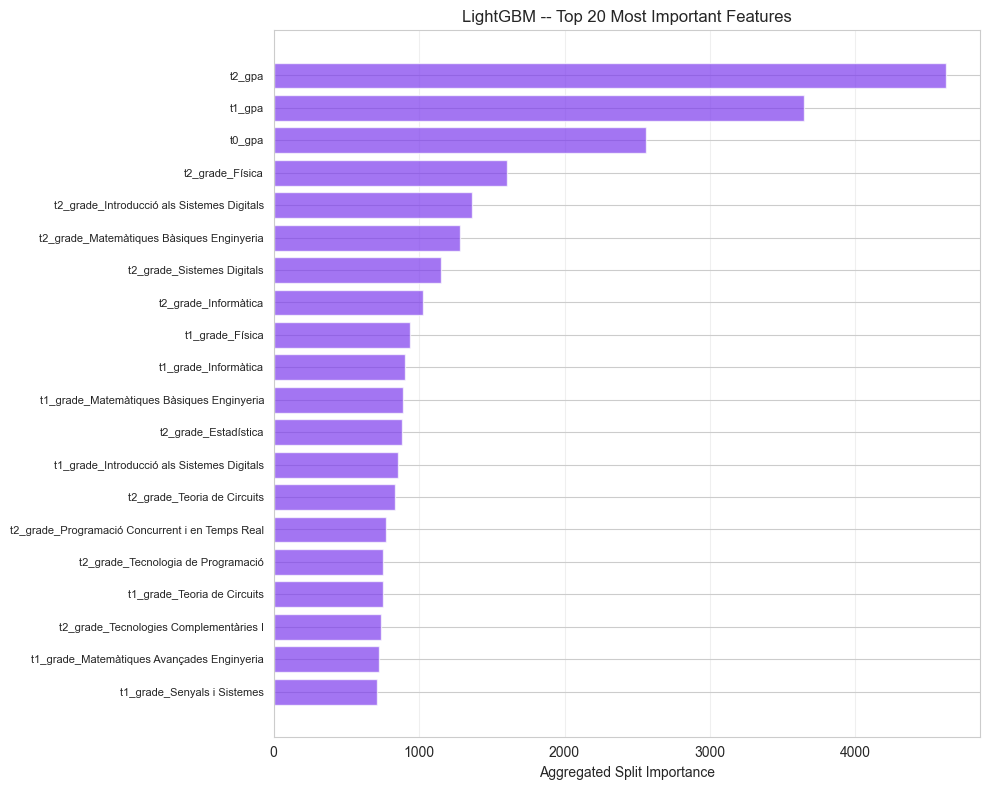

In [6]:
# Build feature names for the flattened input
feature_names = []
for t in range(MICRO_WINDOW_SIZE):
    for c in range(NUM_COURSES):
        cname = labels.get(c, f"C{c}")
        feature_names.append(f"t{t}_enroll_{cname}")
    for c in range(NUM_COURSES):
        cname = labels.get(c, f"C{c}")
        feature_names.append(f"t{t}_grade_{cname}")
    for c in range(NUM_COURSES):
        cname = labels.get(c, f"C{c}")
        feature_names.append(f"t{t}_attempts_{cname}")
    feature_names.append(f"t{t}_gpa")

importance_agg = np.zeros(len(feature_names))
for c_idx, clf in lgb_models.items():
    importance_agg += clf.feature_importances_

df_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_agg
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
top20 = df_imp.head(20)
plt.barh(range(len(top20)), top20["Importance"].values, alpha=0.7, color="#7c3aed")
plt.yticks(range(len(top20)), top20["Feature"].values, fontsize=8)
plt.xlabel("Aggregated Split Importance")
plt.title("LightGBM -- Top 20 Most Important Features")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
metrics = {"MAE": float(mae), "R2": float(r2), "avg_F1": float(avg_f1)}
meta = build_experiment_metadata(
    "lightgbm", "multihot_153_flat",
    {"n_estimators": 200, "max_depth": 4, "num_leaves": 31, "learning_rate": 0.1},
    RANDOM_SEED, len(X_train), len(X_test), f"year >= {SPLIT_YEAR}"
)
json_path, csv_path = export_results("lightgbm_forecasting", metrics, df_per_course, meta)
print(f"Saved: {json_path}")
print(f"       {csv_path}")

Saved: /Users/anassanhari/EPSEM/TFM/educast/results/lightgbm_forecasting_20260510_075826.json
       /Users/anassanhari/EPSEM/TFM/educast/results/lightgbm_forecasting_20260510_075826_per_course.csv
